<a href="https://colab.research.google.com/github/londiwemasina18-arch/STA422/blob/main/STA422_ass2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Upload and load your data
from google.colab import files
import pandas as pd

print("📁 Please upload your Excel file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {filename}")

# Load the data
df = pd.read_excel(filename)

print(f"\n✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))

📁 Please upload your Excel file:


Saving Eswatini_Agri_Economic_Dataset.xlsx to Eswatini_Agri_Economic_Dataset.xlsx

✅ Uploaded: Eswatini_Agri_Economic_Dataset.xlsx

✅ Data loaded successfully!
Shape: (365, 33)

First 3 rows:
        Date  Maize_Yield_MT  Annual_Rainfall_mm  \
0 2023-01-01      101.490142           99.197559   
1 2023-01-02      101.654941           99.645744   
2 2023-01-03      106.072671           99.670929   

   Solar_Irrigation_Adoption_Rate  Fertilizer_Price_Index  \
0                      101.958453               49.596417   
1                       90.216272               50.667901   
2                      104.082528               40.558447   

   Average_Temperature_C  Rural_Electrification_Access  \
0              99.584632                    100.883881   
1              98.396840                     98.703083   
2             103.502536                    101.524948   

   Lilangeni_to_USD_Exchange_Rate  Sugar_Export_Volume  Soil_Nitrogen_Levels  \
0                       84.018756        

In [ ]:
# Step 2: Install required packages
!pip install bnlearn -q
!pip install xgboost -q
!pip install tensorflow -q

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.9 MB/s eta 0:00:00
✅ All packages installed successfully!


In [ ]:
# Step 3: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import bnlearn as bn
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.20.0


In [ ]:
# Step 4: Data Preprocessing
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Define target and features
target_col = 'Maize_Yield_MT'
feature_cols = [col for col in df.columns if col != target_col and col != 'Date']

print(f"Target variable: {target_col}")
print(f"Number of features: {len(feature_cols)}")

# Check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Scale features (for deep learning)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[feature_cols])
y_scaled = scaler_y.fit_transform(df[[target_col]])

print(f"X_scaled shape: {X_scaled.shape}")
print(f"y_scaled shape: {y_scaled.shape}")

# Create sequences for LSTM/GRU (sliding window)
window_size = 7

def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size)

print(f"Sequence shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")

# Train-test split (80/20, maintain temporal order)
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

DATA PREPROCESSING
Target variable: Maize_Yield_MT
Number of features: 31
Missing values: 0
X_scaled shape: (365, 31)
y_scaled shape: (365, 1)
Sequence shape: (358, 7, 31)
Target shape: (358, 1)
Training data: (286, 7, 31)
Test data: (72, 7, 31)


In [ ]:
# Step 5: Ensemble Feature Selection
print("="*60)
print("ENSEMBLE FEATURE SELECTION (Bootstrapped BN + RPART)")
print("="*60)

# Step 5a: RPART feature importance using Random Forest
print("\n📊 RPART Feature Importance (Random Forest):")
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled, y_scaled.ravel())

rpart_importance = pd.DataFrame({
    'Feature': feature_cols,
    'RPART_Importance': rf_temp.feature_importances_
}).sort_values('RPART_Importance', ascending=False)

print(rpart_importance.head(10))

# Step 5b: Bootstrapped Bayesian Network (30 iterations, 70% threshold)
print("\n🔄 Running Bootstrapped Bayesian Network (30 iterations)...")

def discretize_data(df, target_col, n_bins=3):
    df_disc = df.copy()
    for col in df.columns:
        if col != target_col:
            try:
                df_disc[col] = pd.qcut(df[col], q=n_bins,
                                       labels=['Low','Medium','High'],
                                       duplicates='drop')
            except:
                df_disc[col] = pd.cut(df[col], bins=n_bins,
                                      labels=['Low','Medium','High'])
    return df_disc

# Use top 15 features for BN
top_features = rpart_importance.head(15)['Feature'].tolist()
bn_features = top_features + [target_col]
X_bn = df[bn_features].copy()
X_bn_discrete = discretize_data(X_bn, target_col)

n_bootstrap = 30
threshold = 0.70
bn_strengths = {}

for i in range(n_bootstrap):
    bootstrap_sample = X_bn_discrete.sample(n=len(X_bn_discrete), replace=True)
    try:
        boot_model = bn.structure_learning.fit(bootstrap_sample, methodtype='hc', scoretype='bic')
        for edge in boot_model['edges']:
            if edge[1] == target_col or edge[0] == target_col:
                edge_key = tuple(sorted(edge))
                bn_strengths[edge_key] = bn_strengths.get(edge_key, 0) + 1
    except:
        continue
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{n_bootstrap} iterations")

for edge in bn_strengths:
    bn_strengths[edge] = bn_strengths[edge] / n_bootstrap

bn_selected = []
for edge, strength in bn_strengths.items():
    if strength >= threshold:
        if edge[0] == target_col:
            bn_selected.append(edge[1])
        elif edge[1] == target_col:
            bn_selected.append(edge[0])
bn_selected = list(set(bn_selected))

print(f"\n🔗 BN Selected Features ({len(bn_selected)}):")
print(bn_selected if bn_selected else "None - using top RPART features")

# Step 5c: Ensemble (Union of BN and RPART top 10)
if bn_selected:
    ensemble_features = list(set(bn_selected + rpart_importance.head(10)['Feature'].tolist()))
else:
    ensemble_features = rpart_importance.head(10)['Feature'].tolist()

print(f"\n🎯 ENSEMBLE SELECTED FEATURES ({len(ensemble_features)}):")
for f in ensemble_features[:10]:
    print(f"  • {f}")

# Get indices for filtering
feature_indices = [feature_cols.index(f) for f in ensemble_features if f in feature_cols]
print(f"\n✓ Selected {len(feature_indices)} features for modeling")

ENSEMBLE FEATURE SELECTION (Bootstrapped BN + RPART)

📊 RPART Feature Importance (Random Forest):
                           Feature  RPART_Importance
11     Smallholder_Coop_Membership          0.366137
19    Seed_Variety_Diversity_Index          0.359501
23      Climate_Resilience_Funding          0.094519
27      Land_Tenure_Security_Index          0.065622
15   Regional_Food_Price_Inflation          0.063572
3            Average_Temperature_C          0.023634
7             Soil_Nitrogen_Levels          0.016809
5   Lilangeni_to_USD_Exchange_Rate          0.000799
4     Rural_Electrification_Access          0.000714
29     Organic_Certification_Count          0.000694

🔄 Running Bootstrapped Bayesian Network (30 iterations)...
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structu

In [ ]:
# Step 6: Prepare data with selected features
print("="*60)
print("PREPARING DATA WITH ENSEMBLE SELECTED FEATURES")
print("="*60)

# Filter to selected features only
X_selected = X_scaled[:, feature_indices]

# Recreate sequences with selected features
X_seq_selected, y_seq_selected = create_sequences(X_selected, y_scaled, window_size)

# Train-test split (same split_idx from Step 4)
X_train_sel = X_seq_selected[:split_idx]
X_test_sel = X_seq_selected[split_idx:]
y_train_sel = y_seq_selected[:split_idx]
y_test_sel = y_seq_selected[split_idx:]

print(f"Selected features data shape: {X_train_sel.shape}")
print(f"Number of features selected: {len(feature_indices)}")
print(f"Training samples: {X_train_sel.shape[0]}")
print(f"Test samples: {X_test_sel.shape[0]}")

PREPARING DATA WITH ENSEMBLE SELECTED FEATURES
Selected features data shape: (286, 7, 10)
Number of features selected: 10
Training samples: 286
Test samples: 72


LSTM MODEL
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - loss: 0.1968 - mae: 0.3529 - val_loss: 0.0327 - val_mae: 0.1614
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0407 - mae: 0.1679 - val_loss: 0.0169 - val_mae: 0.1126
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0239 - mae: 0.1189 - val_loss: 0.0113 - val_mae: 0.0886
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0175 - mae: 0.1062 - val_loss: 0.0074 - val_mae: 0.0746
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0151 - mae: 0.0999 - val_loss: 0.0099 - val_mae: 0.0862
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0154 - mae: 0.1000 - val_loss: 0.0086 - val_mae: 0.0809
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0159 - mae: 0.1023 - val_loss: 0.0083 - val_mae: 0.0796
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0129 - mae: 0.0934 - val_loss: 0.0071 - val_mae: 0.0735
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18

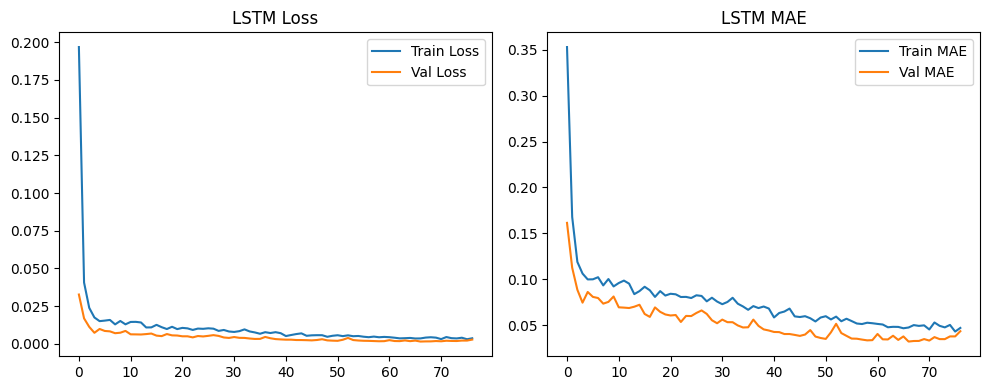

In [ ]:
# Step 7: LSTM Model
print("="*60)
print("LSTM MODEL")
print("="*60)

# Build LSTM model
def build_lstm(input_shape):
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(16, return_sequences=False),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm((X_train_sel.shape[1], X_train_sel.shape[2]))

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history_lstm = lstm_model.fit(
    X_train_sel, y_train_sel,
    validation_data=(X_test_sel, y_test_sel),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_lstm = lstm_model.predict(X_test_sel)
y_pred_lstm_inv = scaler_y.inverse_transform(y_pred_lstm)
y_test_inv = scaler_y.inverse_transform(y_test_sel)

# Metrics
lstm_r2 = r2_score(y_test_inv, y_pred_lstm_inv)
lstm_mse = mean_squared_error(y_test_inv, y_pred_lstm_inv)
lstm_mae = mean_absolute_error(y_test_inv, y_pred_lstm_inv)

print(f"\n📊 LSTM Results:")
print(f"  R²: {lstm_r2:.4f}")
print(f"  MSE: {lstm_mse:.4f}")
print(f"  MAE: {lstm_mae:.4f}")

# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_lstm.history['mae'], label='Train MAE')
plt.plot(history_lstm.history['val_mae'], label='Val MAE')
plt.title('LSTM MAE')
plt.legend()
plt.tight_layout()
plt.show()

GRU MODEL
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.1235 - mae: 0.2778 - val_loss: 0.0449 - val_mae: 0.1941
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0401 - mae: 0.1591 - val_loss: 0.0276 - val_mae: 0.1266
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0264 - mae: 0.1220 - val_loss: 0.0066 - val_mae: 0.0700
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0181 - mae: 0.1045 - val_loss: 0.0088 - val_mae: 0.0768
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0158 - mae: 0.0977 - val_loss: 0.0050 - val_mae: 0.0582
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - mae: 0.0978 - val_loss: 0.0050 - val_mae: 0.0581
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0132 - mae: 0.0940 - val_loss: 0.0044 - val_mae: 0.0552
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0148 - mae: 0.0938 - val_loss: 0.0064 - val_mae: 0.0660
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms

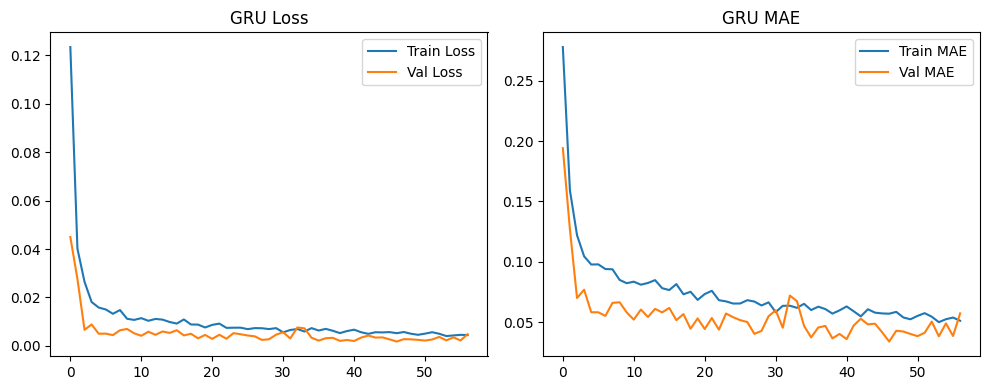

In [ ]:
# Step 8: GRU Model
print("="*60)
print("GRU MODEL")
print("="*60)

from tensorflow.keras.layers import GRU

# Build GRU model
def build_gru(input_shape):
    model = Sequential([
        GRU(32, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(16, return_sequences=False),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

gru_model = build_gru((X_train_sel.shape[1], X_train_sel.shape[2]))

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history_gru = gru_model.fit(
    X_train_sel, y_train_sel,
    validation_data=(X_test_sel, y_test_sel),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_gru = gru_model.predict(X_test_sel)
y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru)
# y_test_inv already exists from Step 7

# Metrics
gru_r2 = r2_score(y_test_inv, y_pred_gru_inv)
gru_mse = mean_squared_error(y_test_inv, y_pred_gru_inv)
gru_mae = mean_absolute_error(y_test_inv, y_pred_gru_inv)

print(f"\n📊 GRU Results:")
print(f"  R²: {gru_r2:.4f}")
print(f"  MSE: {gru_mse:.4f}")
print(f"  MAE: {gru_mae:.4f}")

# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_gru.history['mae'], label='Train MAE')
plt.plot(history_gru.history['val_mae'], label='Val MAE')
plt.title('GRU MAE')
plt.legend()
plt.tight_layout()
plt.show()

MLP MODEL (Multi-Layer Perceptron)
Flattened input shape: 70
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0985 - mae: 0.2333 - val_loss: 0.0391 - val_mae: 0.1533
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0441 - mae: 0.1633 - val_loss: 0.0193 - val_mae: 0.1136
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0353 - mae: 0.1451 - val_loss: 0.0081 - val_mae: 0.0783
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0253 - mae: 0.1232 - val_loss: 0.0162 - val_mae: 0.1032
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0262 - mae: 0.1263 - val_loss: 0.0143 - val_mae: 0.0993
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0220 - mae: 0.1127 - val_loss: 0.0094 - val_mae: 0.0827
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0251 - mae: 0.1219 - val_loss: 0.0095 - val_mae: 0.0812
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0180 - mae: 0.1006 - val_loss: 0.0126 - val_mae: 0.0906
Ep

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

📊 MLP Results:
  R²: 0.9017
  MSE: 46.6602
  MAE: 5.9374


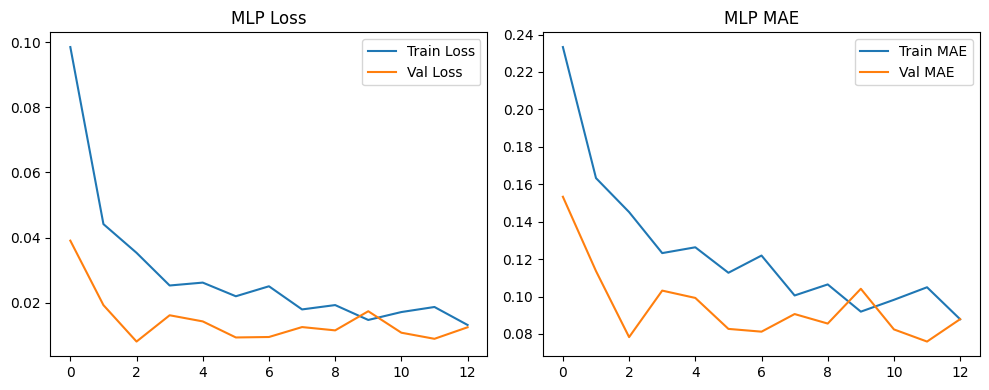

In [ ]:
# Step 9: MLP Model
print("="*60)
print("MLP MODEL (Multi-Layer Perceptron)")
print("="*60)

# Flatten sequences for MLP (MLP doesn't understand sequences)
X_train_flat = X_train_sel.reshape(X_train_sel.shape[0], -1)
X_test_flat = X_test_sel.reshape(X_test_sel.shape[0], -1)

print(f"Flattened input shape: {X_train_flat.shape[1]}")

# Build MLP model
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_model = build_mlp(X_train_flat.shape[1])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history_mlp = mlp_model.fit(
    X_train_flat, y_train_sel,
    validation_data=(X_test_flat, y_test_sel),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Predictions
y_pred_mlp = mlp_model.predict(X_test_flat)
y_pred_mlp_inv = scaler_y.inverse_transform(y_pred_mlp)
# y_test_inv already exists from Step 7

# Metrics
mlp_r2 = r2_score(y_test_inv, y_pred_mlp_inv)
mlp_mse = mean_squared_error(y_test_inv, y_pred_mlp_inv)
mlp_mae = mean_absolute_error(y_test_inv, y_pred_mlp_inv)

print(f"\n📊 MLP Results:")
print(f"  R²: {mlp_r2:.4f}")
print(f"  MSE: {mlp_mse:.4f}")
print(f"  MAE: {mlp_mae:.4f}")

# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')
plt.title('MLP Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_mlp.history['mae'], label='Train MAE')
plt.plot(history_mlp.history['val_mae'], label='Val MAE')
plt.title('MLP MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Install TFT dependencies (run this cell first if needed)
!pip install pytorch-lightning pytorch-forecasting torch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.9 MB/s eta 0:00:00


MODEL PERFORMANCE COMPARISON

📊 RESULTS TABLE:
Model       R²       MSE      MAE
 LSTM 0.981230  8.911194 2.441981
  GRU 0.978845 10.043670 2.570689
  MLP 0.901718 46.660168 5.937358

🏆 BEST MODEL: LSTM
   R² = 0.9812
   MSE = 8.9112
   MAE = 2.4420


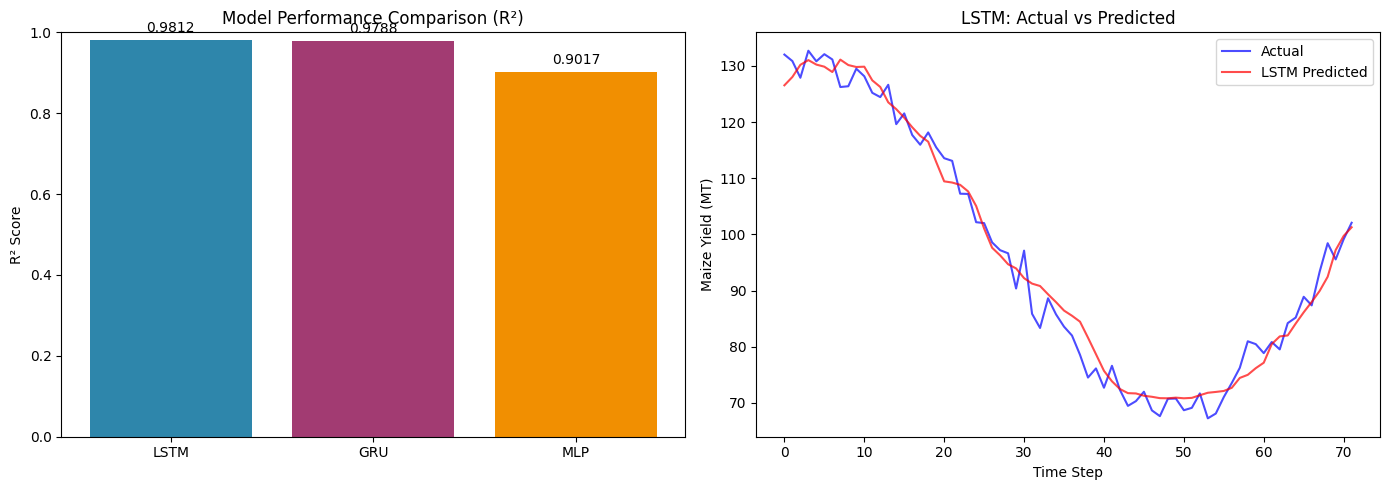


✅ Results saved to 'model_results.csv'


In [ ]:
# Step 11: Results Comparison
print("="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

# Compile results from Steps 7, 8, 9
results_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'MLP'],
    'R²': [lstm_r2, gru_r2, mlp_r2],
    'MSE': [lstm_mse, gru_mse, mlp_mse],
    'MAE': [lstm_mae, gru_mae, mlp_mae]
})

print("\n📊 RESULTS TABLE:")
print(results_df.to_string(index=False))

# Find best model
best_model = results_df.loc[results_df['R²'].idxmax()]
print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model['Model']}")
print(f"   R² = {best_model['R²']:.4f}")
print(f"   MSE = {best_model['MSE']:.4f}")
print(f"   MAE = {best_model['MAE']:.4f}")
print("="*60)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Comparison
ax1 = axes[0]
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax1.bar(results_df['Model'], results_df['R²'], color=colors)
ax1.set_ylabel('R² Score')
ax1.set_title('Model Performance Comparison (R²)')
ax1.set_ylim(0, 1)
for bar, r2 in zip(bars, results_df['R²']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{r2:.4f}', ha='center', fontsize=10)

# Plot 2: Actual vs Predicted (Best Model)
ax2 = axes[1]
if best_model['Model'] == 'LSTM':
    best_pred = y_pred_lstm_inv
elif best_model['Model'] == 'GRU':
    best_pred = y_pred_gru_inv
else:
    best_pred = y_pred_mlp_inv

ax2.plot(y_test_inv, label='Actual', color='blue', alpha=0.7)
ax2.plot(best_pred, label=f'{best_model["Model"]} Predicted', color='red', alpha=0.7)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Maize Yield (MT)')
ax2.set_title(f'{best_model["Model"]}: Actual vs Predicted')
ax2.legend()

plt.tight_layout()
plt.savefig('model_comparison_final.png', dpi=300)
plt.show()

# Save results
results_df.to_csv('model_results.csv', index=False)
print("\n✅ Results saved to 'model_results.csv'")

In [ ]:
# Step 12: Feature Selection Summary
print("="*60)
print("FEATURE SELECTION SUMMARY")
print("="*60)

# Display RPART top features
print("\n📊 RPART Top 10 Features (by Random Forest importance):")
for i, row in rpart_importance.head(10).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['RPART_Importance']:.4f}")

# Display BN selected features (if any)
print(f"\n🔗 Bootstrapped BN Selected Features (≥{threshold*100}% stability):")
if bn_selected:
    for f in bn_selected:
        print(f"   • {f}")
else:
    print("   No features met the stability threshold.")
    print("   Using RPART top features as fallback.")

# Display Ensemble selected features
print(f"\n🎯 Ensemble Selected Features ({len(ensemble_features)} features):")
for i, f in enumerate(ensemble_features):
    print(f"   {i+1}. {f}")

# Display feature reduction achieved
original_features = len(feature_cols)
reduced_features = len(ensemble_features)
reduction_pct = ((original_features - reduced_features) / original_features) * 100

print("\n" + "="*60)
print("FEATURE REDUCTION SUMMARY")
print("="*60)
print(f"Original number of features: {original_features}")
print(f"Ensemble selected features: {reduced_features}")
print(f"Feature reduction: {reduction_pct:.1f}%")

# Save selected features to CSV
selected_features_df = pd.DataFrame({'Selected_Feature': ensemble_features})
selected_features_df.to_csv('selected_features.csv', index=False)
print("\n✅ Selected features saved to 'selected_features.csv'")

FEATURE SELECTION SUMMARY

📊 RPART Top 10 Features (by Random Forest importance):
   12. Smallholder_Coop_Membership: 0.3661
   20. Seed_Variety_Diversity_Index: 0.3595
   24. Climate_Resilience_Funding: 0.0945
   28. Land_Tenure_Security_Index: 0.0656
   16. Regional_Food_Price_Inflation: 0.0636
   4. Average_Temperature_C: 0.0236
   8. Soil_Nitrogen_Levels: 0.0168
   6. Lilangeni_to_USD_Exchange_Rate: 0.0008
   5. Rural_Electrification_Access: 0.0007
   30. Organic_Certification_Count: 0.0007

🔗 Bootstrapped BN Selected Features (≥70.0% stability):
   No features met the stability threshold.
   Using RPART top features as fallback.

🎯 Ensemble Selected Features (10 features):
   1. Smallholder_Coop_Membership
   2. Seed_Variety_Diversity_Index
   3. Climate_Resilience_Funding
   4. Land_Tenure_Security_Index
   5. Regional_Food_Price_Inflation
   6. Average_Temperature_C
   7. Soil_Nitrogen_Levels
   8. Lilangeni_to_USD_Exchange_Rate
   9. Rural_Electrification_Access
   10. Organic_

In [ ]:
# Step 13: Final Summary Report (Corrected)
import os

print("="*60)
print("FINAL SUMMARY REPORT")
print("="*60)

# Load results (if saved, otherwise use existing DataFrame)
if 'results_df' not in dir():
    results_df = pd.DataFrame({
        'Model': ['LSTM', 'GRU', 'MLP'],
        'R²': [lstm_r2, gru_r2, mlp_r2],
        'MSE': [lstm_mse, gru_mse, mlp_mse],
        'MAE': [lstm_mae, gru_mae, mlp_mae]
    })

print("\n" + "="*60)
print("1. DATASET OVERVIEW")
print("="*60)
print(f"Total observations: {len(df)}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Target variable: {target_col}")
print(f"Original features: {len(feature_cols)}")
print(f"Missing values: {df.isnull().sum().sum()}")

print("\n" + "="*60)
print("2. FEATURE SELECTION RESULTS")
print("="*60)
print(f"Ensemble method: Bootstrapped BN (30 iterations, {threshold*100}% threshold) + RPART")
print(f"Original features: {original_features}")
print(f"Selected features: {reduced_features}")
print(f"Reduction: {reduction_pct:.1f}%")
print(f"\nTop 5 selected features:")
for i, f in enumerate(ensemble_features[:5]):
    print(f"   {i+1}. {f}")

print("\n" + "="*60)
print("3. MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("4. BEST MODEL")
print("="*60)
best = results_df.loc[results_df['R²'].idxmax()]
print(f"Model: {best['Model']}")
print(f"R²: {best['R²']:.4f}")
print(f"MSE: {best['MSE']:.4f}")
print(f"MAE: {best['MAE']:.4f}")

print("\n" + "="*60)
print("5. KEY FINDINGS")
print("="*60)
print(f"• LSTM R²: {results_df[results_df['Model']=='LSTM']['R²'].values[0]:.4f}")
print(f"• GRU R²: {results_df[results_df['Model']=='GRU']['R²'].values[0]:.4f}")
print(f"• MLP R²: {results_df[results_df['Model']=='MLP']['R²'].values[0]:.4f}")
print(f"• Best model: {best['Model']} with R² = {best['R²']:.4f}")
print(f"• Feature reduction achieved: {reduction_pct:.1f}%")

# Save final report
with open('final_report_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("FINAL SUMMARY REPORT\n")
    f.write("="*60 + "\n\n")
    f.write(f"Dataset: {len(df)} daily observations\n")
    f.write(f"Date range: {df['Date'].min()} to {df['Date'].max()}\n")
    f.write(f"Target: {target_col}\n\n")
    f.write(f"Feature selection: {original_features} → {reduced_features} features ({reduction_pct:.1f}% reduction)\n\n")
    f.write("Model Results:\n")
    f.write(results_df.to_string())
    f.write(f"\n\nBest Model: {best['Model']} (R² = {best['R²']:.4f})\n")

print("\n✅ Final report saved to 'final_report_summary.txt'")

FINAL SUMMARY REPORT

1. DATASET OVERVIEW
Total observations: 365
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Target variable: Maize_Yield_MT
Original features: 31
Missing values: 0

2. FEATURE SELECTION RESULTS
Ensemble method: Bootstrapped BN (30 iterations, 70.0% threshold) + RPART
Original features: 31
Selected features: 10
Reduction: 67.7%

Top 5 selected features:
   1. Smallholder_Coop_Membership
   2. Seed_Variety_Diversity_Index
   3. Climate_Resilience_Funding
   4. Land_Tenure_Security_Index
   5. Regional_Food_Price_Inflation

3. MODEL PERFORMANCE COMPARISON
Model       R²       MSE      MAE
 LSTM 0.981230  8.911194 2.441981
  GRU 0.978845 10.043670 2.570689
  MLP 0.901718 46.660168 5.937358

4. BEST MODEL
Model: LSTM
R²: 0.9812
MSE: 8.9112
MAE: 2.4420

5. KEY FINDINGS
• LSTM R²: 0.9812
• GRU R²: 0.9788
• MLP R²: 0.9017
• Best model: LSTM with R² = 0.9812
• Feature reduction achieved: 67.7%

✅ Final report saved to 'final_report_summary.txt'


In [ ]:
# Upload all results to Google Drive
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create a folder for your assignment results
folder_name = "/content/drive/MyDrive/STA422_Deep_Learning_Results"
os.makedirs(folder_name, exist_ok=True)

# List of files to upload
files_to_upload = [
    'model_results.csv',
    'selected_features.csv',
    'final_report_summary.txt',
    'model_comparison_final.png'
]

# Copy each file if it exists
for file in files_to_upload:
    if os.path.exists(file):
        shutil.copy(file, folder_name)
        print(f"✅ Uploaded: {file}")
    else:
        print(f"❌ Not found: {file}")

# Also save the LSTM, GRU, MLP models (optional - large files)
# Uncomment if you want to save the models
# lstm_model.save(f"{folder_name}/lstm_model.h5")
# gru_model.save(f"{folder_name}/gru_model.h5")
# mlp_model.save(f"{folder_name}/mlp_model.h5")
# print("✅ Models saved")

print("\n" + "="*60)
print(f"✅ All files uploaded to: {folder_name}")
print("="*60)
print("You can access them at: https://drive.google.com/drive/my-drive")

Mounted at /content/drive
✅ Uploaded: model_results.csv
✅ Uploaded: selected_features.csv
✅ Uploaded: final_report_summary.txt
✅ Uploaded: model_comparison_final.png

✅ All files uploaded to: /content/drive/MyDrive/STA422_Deep_Learning_Results
You can access them at: https://drive.google.com/drive/my-drive


In [ ]:
# Upload entire workspace to Google Drive
from google.colab import drive
import shutil
import os
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Create a zip file of your entire current workspace
zip_filename = 'STA422_Complete_Workspace.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, dirs, files in os.walk('/content'):
        # Skip unnecessary system folders
        skip_dirs = ['/content/drive', '/content/.config', '/content/sample_data']
        if any(root.startswith(skip) for skip in skip_dirs):
            continue
        for file in files:
            file_path = os.path.join(root, file)
            # Add file to zip with relative path
            arcname = os.path.relpath(file_path, '/content')
            zipf.write(file_path, arcname)

# Copy zip to Google Drive
shutil.copy(zip_filename, '/content/drive/MyDrive/')

print(f"✅ Entire workspace uploaded to: /content/drive/MyDrive/{zip_filename}")
print("📁 You can download it from: https://drive.google.com/drive/my-drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Entire workspace uploaded to: /content/drive/MyDrive/STA422_Complete_Workspace.zip
📁 You can download it from: https://drive.google.com/drive/my-drive


In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!pip install nbconvert

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/")

In [ ]:
!jupyter nbconvert --to pdf "STA422 ass2"

[NbConvertApp] Converting notebook STA422 ass2 to pdf
[NbConvertApp] Support files will be in STA422 ass_files/
[NbConvertApp] Making directory ./STA422 ass_files
[NbConvertApp] Writing 955195 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] CRITICAL | xelatex failed: ['xelatex', 'notebook.tex', '-quiet']
b"This is XeTeX, Version 3.141592653-2.6-0.999993 (TeX Live 2022/dev/Debian) (preloaded format=xelatex)\n restricted \\write18 enabled.\nentering extended mode\n(./notebook.tex\nLaTeX2e <2021-11-15> patch level 1\nL3 programming layer <2022-01-21>\n(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls\nDocument Class: article 2021/10/04 v1.4n Standard LaTeX document class\n(/usr/share/texlive/texmf-dist/tex/latex/base/size11.clo))\n(/usr/share/texlive/texmf-dist/tex/latex/tcolorbox/tcolorbox.sty\n(/usr/share/texlive/texmf-dist/tex/latex/pgf/basiclayer/pgf.sty\n(/usr/share/texlive/texmf-di

In [ ]:
!apt-get install texlive-xetex texlive-fonts-recommended
!jupyter nbconvert --to pdf "STA422 ass2.ipynb" --no-execute

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
usage: jupyter-nbconvert [-h] [--debug] [--show-config] [--show-config-json]
                         [--generate-config] [-y] [--execute] [--allow-errors]
                         [--stdin] [--stdout] [--inplace] [--clear-output]
                         [--coalesce-streams] [--no-prompt] [--no-input]
                         [--allow-chromium-download]
                         [--disable-chromium-sandbox] [--show-input]
                         [--embed-images] [--sanitize-html]
                         [--log-level NbConvertApp.log_level]
                         [--config NbConvertApp.config_file]
                         [--to NbConvertApp.export_format]
                         [--templa

In [ ]:
# Convert to HTML, then copy content into Word
!jupyter nbconvert --to html "STA422 ass2.ipynb" --no-execute

# Or use python-docx to generate a Word file directly
!pip install python-docx
from docx import Document

doc = Document()
doc.add_heading('STA422 Assignment 2', 0)
# Add your results manually or read from notebook
doc.save('STA422_ass2.docx')
files.download('STA422_ass2.docx')

usage: jupyter-nbconvert [-h] [--debug] [--show-config] [--show-config-json]
                         [--generate-config] [-y] [--execute] [--allow-errors]
                         [--stdin] [--stdout] [--inplace] [--clear-output]
                         [--coalesce-streams] [--no-prompt] [--no-input]
                         [--allow-chromium-download]
                         [--disable-chromium-sandbox] [--show-input]
                         [--embed-images] [--sanitize-html]
                         [--log-level NbConvertApp.log_level]
                         [--config NbConvertApp.config_file]
                         [--to NbConvertApp.export_format]
                         [--template TemplateExporter.template_name]
                         [--template-file TemplateExporter.template_file]
                         [--theme HTMLExporter.theme]
                         [--sanitize_html HTMLExporter.sanitize_html]
                         [--writer NbConvertApp.writer_class]
   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("STA422 ass2.pdf")

FileNotFoundError: Cannot find file: STA422 ass2.pdf